# XGBoost Weight Analysis: Dimensionality Reduction and Clustering

This notebook analyzes the feature importance (weights) from XGBoost models trained on Enformer embeddings.

**Analysis Pipeline:**
1. Load feature importance data from XGBoost results
2. Perform dimensionality reduction: PCA, UMAP, t-SNE
3. Apply clustering algorithms: KMeans and GMM on all three reduced dimensions
4. Visualize and interpret results

# XGBoost Weight Analysis: Dimensionality Reduction and Clustering

This notebook analyzes the feature importance (weights) from XGBoost models trained on Enformer embeddings.

**Analysis Pipeline:**
1. Load feature importance data from XGBoost results
2. Perform dimensionality reduction: PCA, UMAP, t-SNE
3. Apply clustering algorithms: KNN and GMM on all three reduced dimensions
4. Visualize and interpret results

## 1. Load XGBoost Feature Importance Data

Feature importance represents which Enformer embedding dimensions are most important for predicting each gene's perturbation response.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import umap
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

/net/dali/home/mscbio/mag1037/miniforge3/envs/chikina_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Paths to feature importance files
gencode_path = '../2_regression/xgboost/enformer_gencode_xgboost_feature_importance_active_guides_CRISPRa_mean_pop_mean.csv'
tss_path = '../2_regression/xgboost/enformer_tss_xgboost_feature_importance_active_guides_CRISPRa_mean_pop_mean.csv'

# Load data
df_gencode = pd.read_csv(gencode_path)
df_tss = pd.read_csv(tss_path)

print(f"Gencode feature importance shape: {df_gencode.shape}")
print(f"TSS feature importance shape: {df_tss.shape}")
print(f"\nNumber of perturbations: {len(df_gencode)}")
print(f"Number of features: {len([col for col in df_gencode.columns if col.startswith('feature_')])}")

# Display first few rows
df_gencode.head()

Gencode feature importance shape: (231, 33)
TSS feature importance shape: (231, 33)

Number of perturbations: 231
Number of features: 32


,perturbation,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31
0,AFF1,0.020936,0.033671,0.030537,0.019697,0.026898,0.032273,0.031296,0.028955,0.030142,...,0.034580,0.032165,0.030897,0.033303,0.031558,0.036981,0.030013,0.034318,0.025228,0.027612
1,ALX1,0.030373,0.032416,0.028406,0.031947,0.023208,0.033909,0.029903,0.033677,0.026318,...,0.039668,0.039144,0.031660,0.032512,0.031966,0.029990,0.032124,0.033196,0.031690,0.032333
2,ALX4,0.079498,0.015057,0.078517,0.020386,0.023982,0.044288,0.026152,0.021441,0.032939,...,0.022810,0.021200,0.015134,0.021965,0.017133,0.013114,0.019638,0.024156,0.020625,0.026767
3,ARID1A,0.020915,0.027104,0.031249,0.028835,0.030702,0.026592,0.030281,0.031924,0.031445,...,0.028995,0.030495,0.033280,0.036521,0.030972,0.033102,0.029255,0.030706,0.031140,0.024737
4,ARID3A,0.032837,0.029746,0.028078,0.034578,0.036564,0.023794,0.024993,0.028282,0.027889,...,0.034208,0.057607,0.029955,0.026154,0.024985,0.024048,0.031104,0.044092,0.028805,0.036393


## 2. Dimensionality Reduction

We'll apply three dimensionality reduction techniques to reduce from 32 dimensions to 2D:
- **PCA**: Linear, preserves global structure
- **t-SNE**: Non-linear, preserves local structure
- **UMAP**: Non-linear, preserves both local and global structure

In [3]:
# Extract feature columns (32 features)
feature_cols = [col for col in df_gencode.columns if col.startswith('feature_')]
print(f"Feature columns: {len(feature_cols)}")

# Extract feature matrices
X_gencode = df_gencode[feature_cols].values
X_tss = df_tss[feature_cols].values
perturbations = df_gencode['perturbation'].values

print(f"\nGencode feature matrix shape: {X_gencode.shape}")
print(f"TSS feature matrix shape: {X_tss.shape}")

# Standardize the features (important for dimensionality reduction)
scaler_gencode = StandardScaler()
scaler_tss = StandardScaler()

X_gencode_scaled = scaler_gencode.fit_transform(X_gencode)
X_tss_scaled = scaler_tss.fit_transform(X_tss)

print("\nFeatures standardized successfully")

Feature columns: 32

Gencode feature matrix shape: (231, 32)
TSS feature matrix shape: (231, 32)

Features standardized successfully


## 3. Clustering Analysis

We'll apply two clustering algorithms on ALL THREE dimensionality reductions:
- **KMeans**: Hard clustering, assigns each point to one cluster
- **GMM (Gaussian Mixture Model)**: Soft clustering, probabilistic assignment

Clustering quality metrics:
- Silhouette Score (higher is better, range [-1, 1])
- Davies-Bouldin Index (lower is better)
- Calinski-Harabasz Score (higher is better)

In [4]:
# PCA
pca_gencode = PCA(n_components=2, random_state=42)
X_gencode_pca = pca_gencode.fit_transform(X_gencode_scaled)

pca_tss = PCA(n_components=2, random_state=42)
X_tss_pca = pca_tss.fit_transform(X_tss_scaled)

print("PCA completed")
print(f"Gencode explained variance: {pca_gencode.explained_variance_ratio_.sum():.4f}")
print(f"TSS explained variance: {pca_tss.explained_variance_ratio_.sum():.4f}")

PCA completed
Gencode explained variance: 0.1704
TSS explained variance: 0.1855


In [5]:
# Perform PCA with ALL components to see full variance explained
pca_full_gencode = PCA(random_state=42)
pca_full_gencode.fit(X_gencode_scaled)

pca_full_tss = PCA(random_state=42)
pca_full_tss.fit(X_tss_scaled)

print(f"Total number of components: {len(pca_full_gencode.components_)}")
print(f"Shape of feature matrix: {X_gencode_scaled.shape}")

Total number of components: 32
Shape of feature matrix: (231, 32)


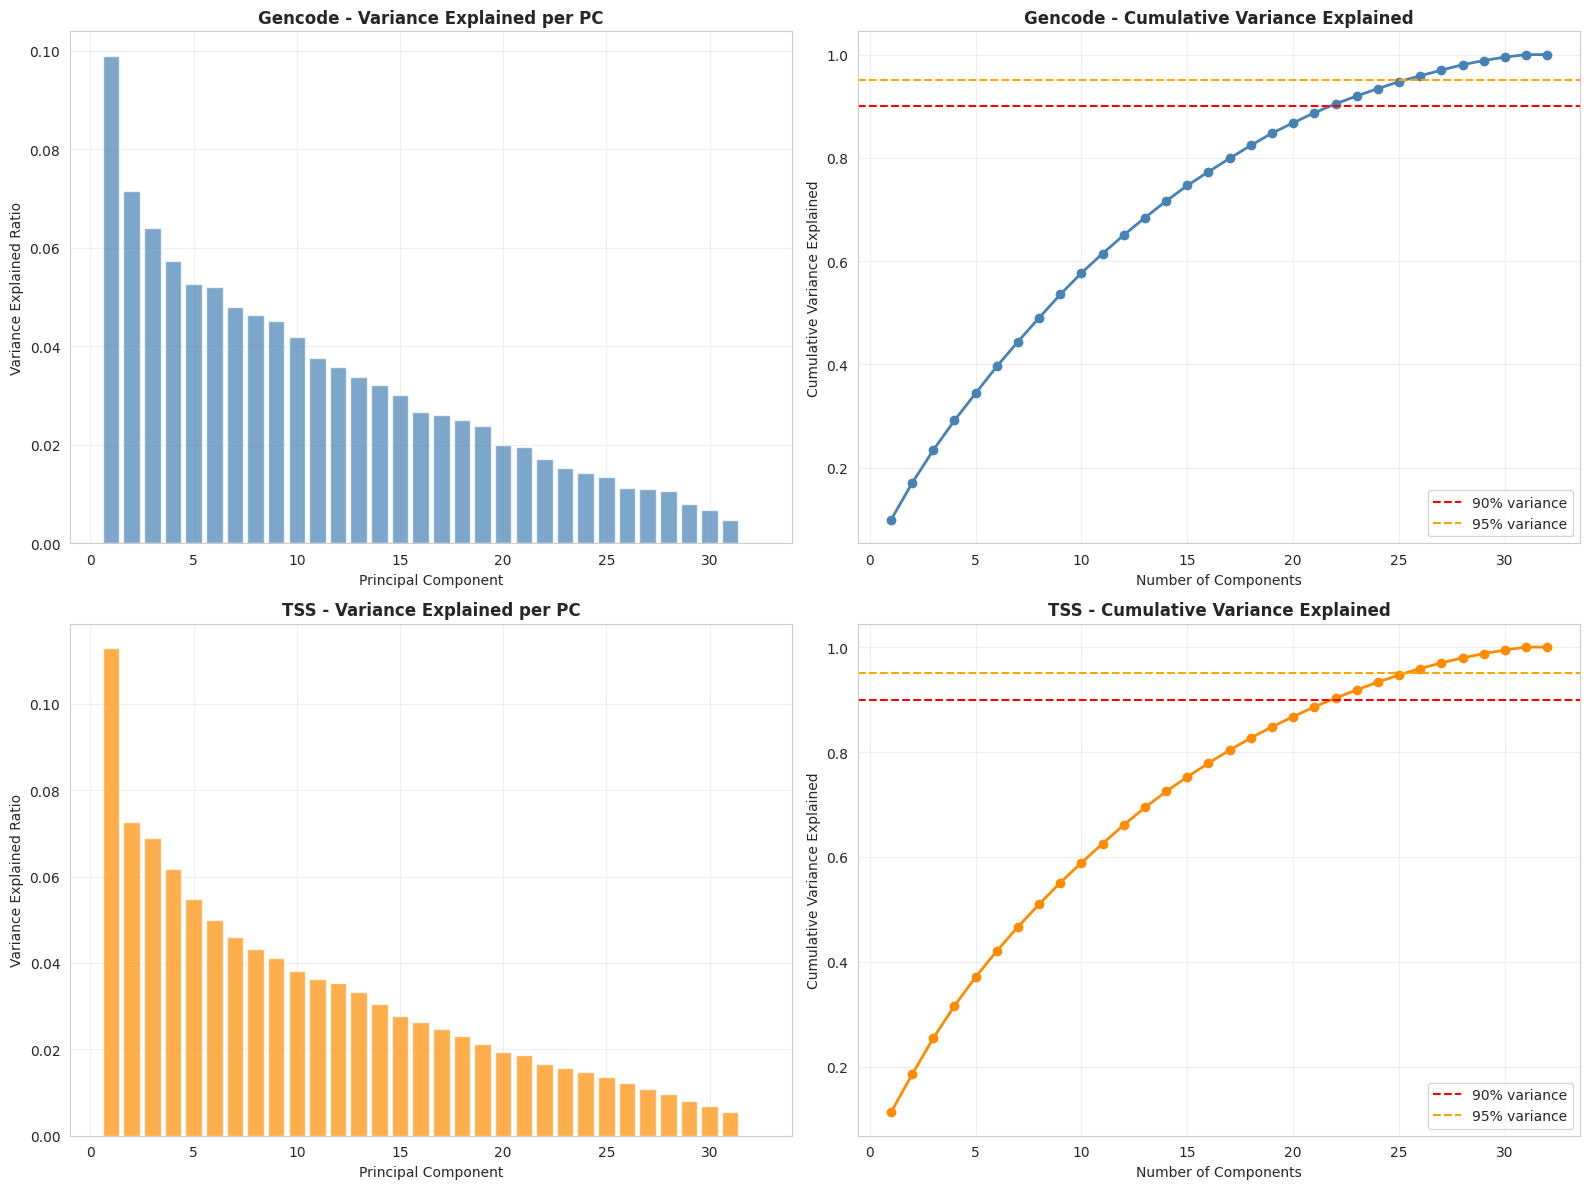


Gencode:
  Components for 90% variance: 22
  Components for 95% variance: 26

TSS:
  Components for 90% variance: 22
  Components for 95% variance: 26


In [6]:
# Create scree plots showing variance explained by each PC
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gencode - Variance explained per component
axes[0, 0].bar(range(1, len(pca_full_gencode.explained_variance_ratio_) + 1), 
               pca_full_gencode.explained_variance_ratio_,
               alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('Principal Component')
axes[0, 0].set_ylabel('Variance Explained Ratio')
axes[0, 0].set_title('Gencode - Variance Explained per PC', fontweight='bold', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# Gencode - Cumulative variance explained
cumsum_gencode = np.cumsum(pca_full_gencode.explained_variance_ratio_)
axes[0, 1].plot(range(1, len(cumsum_gencode) + 1), cumsum_gencode, 
                'o-', linewidth=2, markersize=6, color='steelblue')
axes[0, 1].axhline(y=0.90, color='r', linestyle='--', label='90% variance')
axes[0, 1].axhline(y=0.95, color='orange', linestyle='--', label='95% variance')
axes[0, 1].set_xlabel('Number of Components')
axes[0, 1].set_ylabel('Cumulative Variance Explained')
axes[0, 1].set_title('Gencode - Cumulative Variance Explained', fontweight='bold', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# TSS - Variance explained per component
axes[1, 0].bar(range(1, len(pca_full_tss.explained_variance_ratio_) + 1), 
               pca_full_tss.explained_variance_ratio_,
               alpha=0.7, color='darkorange')
axes[1, 0].set_xlabel('Principal Component')
axes[1, 0].set_ylabel('Variance Explained Ratio')
axes[1, 0].set_title('TSS - Variance Explained per PC', fontweight='bold', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# TSS - Cumulative variance explained
cumsum_tss = np.cumsum(pca_full_tss.explained_variance_ratio_)
axes[1, 1].plot(range(1, len(cumsum_tss) + 1), cumsum_tss, 
                'o-', linewidth=2, markersize=6, color='darkorange')
axes[1, 1].axhline(y=0.90, color='r', linestyle='--', label='90% variance')
axes[1, 1].axhline(y=0.95, color='orange', linestyle='--', label='95% variance')
axes[1, 1].set_xlabel('Number of Components')
axes[1, 1].set_ylabel('Cumulative Variance Explained')
axes[1, 1].set_title('TSS - Cumulative Variance Explained', fontweight='bold', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('pca_variance_explained.png', dpi=300, bbox_inches='tight')
plt.show()

# Find number of components for 90% and 95% variance
n_components_90_gencode = np.argmax(cumsum_gencode >= 0.90) + 1
n_components_95_gencode = np.argmax(cumsum_gencode >= 0.95) + 1
n_components_90_tss = np.argmax(cumsum_tss >= 0.90) + 1
n_components_95_tss = np.argmax(cumsum_tss >= 0.95) + 1

print(f"\nGencode:")
print(f"  Components for 90% variance: {n_components_90_gencode}")
print(f"  Components for 95% variance: {n_components_95_gencode}")
print(f"\nTSS:")
print(f"  Components for 90% variance: {n_components_90_tss}")
print(f"  Components for 95% variance: {n_components_95_tss}")

In [7]:
# t-SNE
tsne_gencode = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_gencode_tsne = tsne_gencode.fit_transform(X_gencode_scaled)

tsne_tss = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tss_tsne = tsne_tss.fit_transform(X_tss_scaled)

print("t-SNE completed")

t-SNE completed


In [8]:
# UMAP
umap_gencode = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_gencode_umap = umap_gencode.fit_transform(X_gencode_scaled)

umap_tss = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_tss_umap = umap_tss.fit_transform(X_tss_scaled)

print("UMAP completed")

UMAP completed


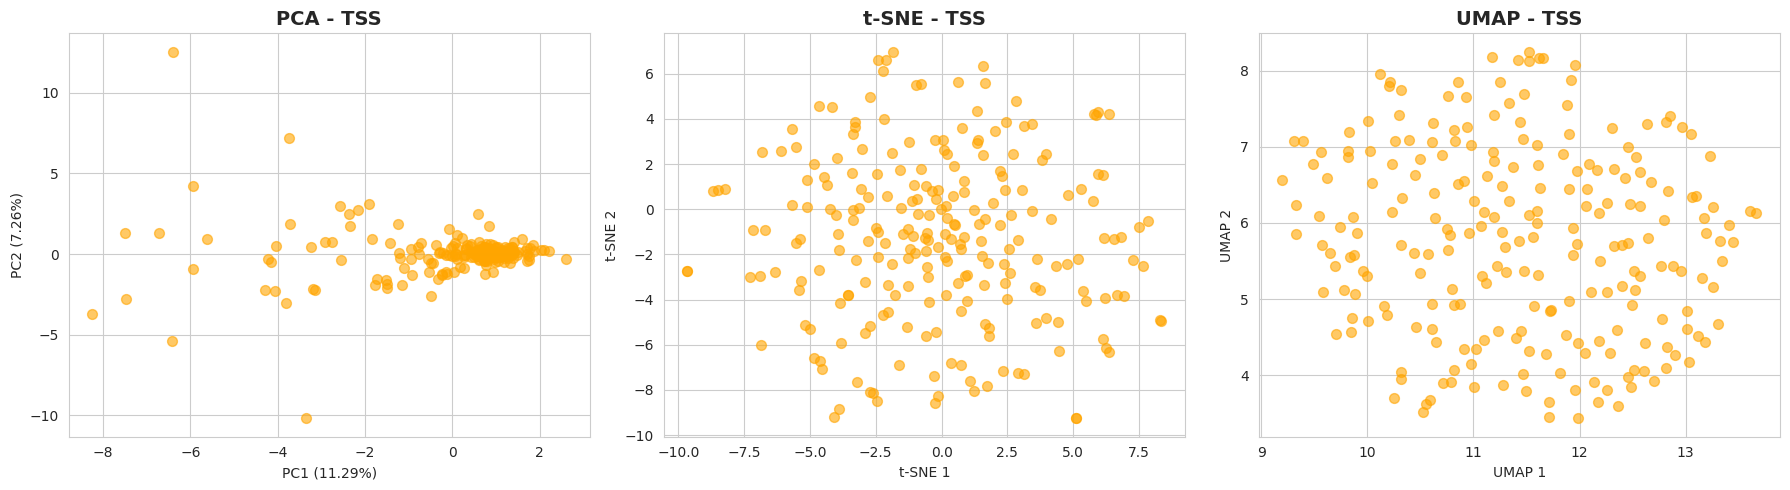

In [9]:
# Visualize all dimensionality reductions for TSS
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_tss_pca[:, 0], X_tss_pca[:, 1], alpha=0.6, s=50, color='orange')
axes[0].set_title('PCA - TSS', fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_tss.explained_variance_ratio_[0]:.2%})')
axes[0].set_ylabel(f'PC2 ({pca_tss.explained_variance_ratio_[1]:.2%})')

axes[1].scatter(X_tss_tsne[:, 0], X_tss_tsne[:, 1], alpha=0.6, s=50, color='orange')
axes[1].set_title('t-SNE - TSS', fontsize=14, fontweight='bold')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

axes[2].scatter(X_tss_umap[:, 0], X_tss_umap[:, 1], alpha=0.6, s=50, color='orange')
axes[2].set_title('UMAP - TSS', fontsize=14, fontweight='bold')
axes[2].set_xlabel('UMAP 1')
axes[2].set_ylabel('UMAP 2')

plt.tight_layout()
# plt.savefig('tss_dimensionality_reduction.png', dpi=300, bbox_inches='tight')
plt.show()

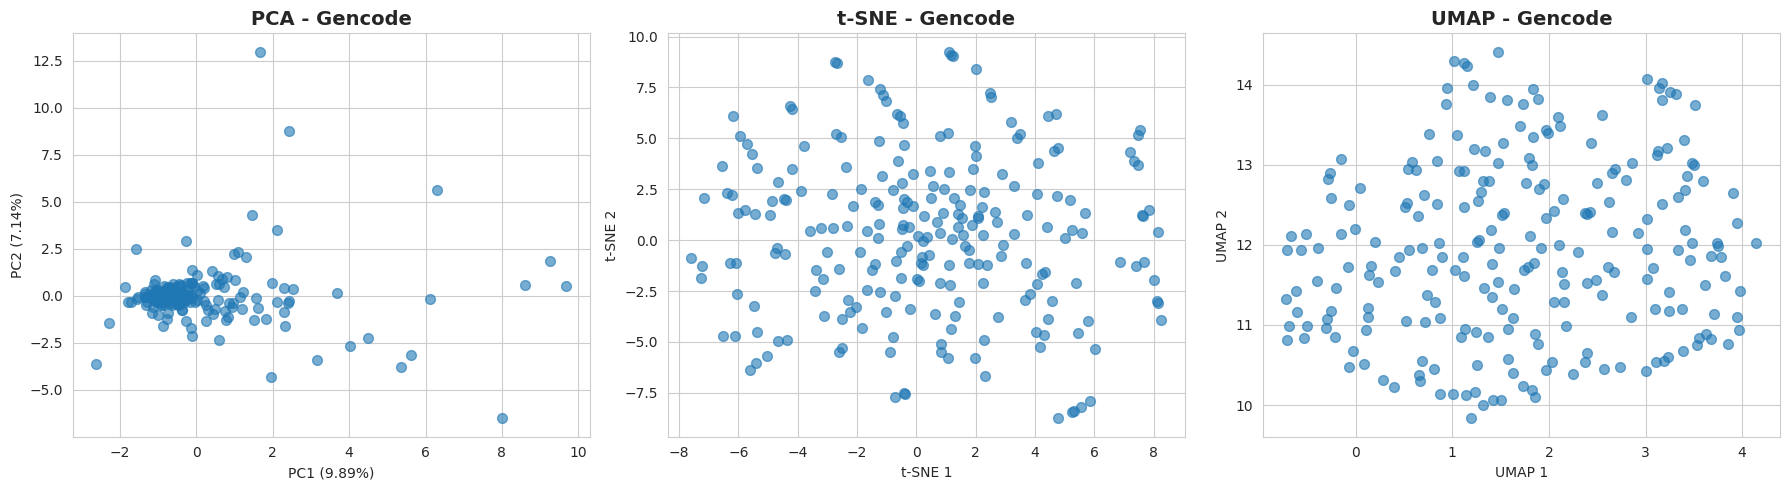

In [10]:
# Visualize all dimensionality reductions for Gencode
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_gencode_pca[:, 0], X_gencode_pca[:, 1], alpha=0.6, s=50)
axes[0].set_title('PCA - Gencode', fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_gencode.explained_variance_ratio_[0]:.2%})')
axes[0].set_ylabel(f'PC2 ({pca_gencode.explained_variance_ratio_[1]:.2%})')

axes[1].scatter(X_gencode_tsne[:, 0], X_gencode_tsne[:, 1], alpha=0.6, s=50)
axes[1].set_title('t-SNE - Gencode', fontsize=14, fontweight='bold')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

axes[2].scatter(X_gencode_umap[:, 0], X_gencode_umap[:, 1], alpha=0.6, s=50)
axes[2].set_title('UMAP - Gencode', fontsize=14, fontweight='bold')
axes[2].set_xlabel('UMAP 1')
axes[2].set_ylabel('UMAP 2')

plt.tight_layout()
# plt.savefig('xgboost_gencode_dimensionality_reduction.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Save Results and Create Summary

In [11]:
# Set optimal number of clusters (adjust this based on the plots above)
optimal_k = 3

def apply_clustering(X, n_clusters=5):
    """Apply both KMeans and GMM clustering."""
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(X)
    
    gmm = GaussianMixture(n_components=n_clusters, random_state=42, n_init=10)
    gmm_labels = gmm.fit_predict(X)
    
    return kmeans_labels, gmm_labels

# Apply clustering to ALL THREE dimensionality reductions for BOTH embeddings

# Gencode
kmeans_labels_gencode_pca, gmm_labels_gencode_pca = apply_clustering(X_gencode_pca, optimal_k)
kmeans_labels_gencode_tsne, gmm_labels_gencode_tsne = apply_clustering(X_gencode_tsne, optimal_k)
kmeans_labels_gencode_umap, gmm_labels_gencode_umap = apply_clustering(X_gencode_umap, optimal_k)

# TSS
kmeans_labels_tss_pca, gmm_labels_tss_pca = apply_clustering(X_tss_pca, optimal_k)
kmeans_labels_tss_tsne, gmm_labels_tss_tsne = apply_clustering(X_tss_tsne, optimal_k)
kmeans_labels_tss_umap, gmm_labels_tss_umap = apply_clustering(X_tss_umap, optimal_k)

print(f"Clustering completed with k={optimal_k} clusters!")

Clustering completed with k=3 clusters!


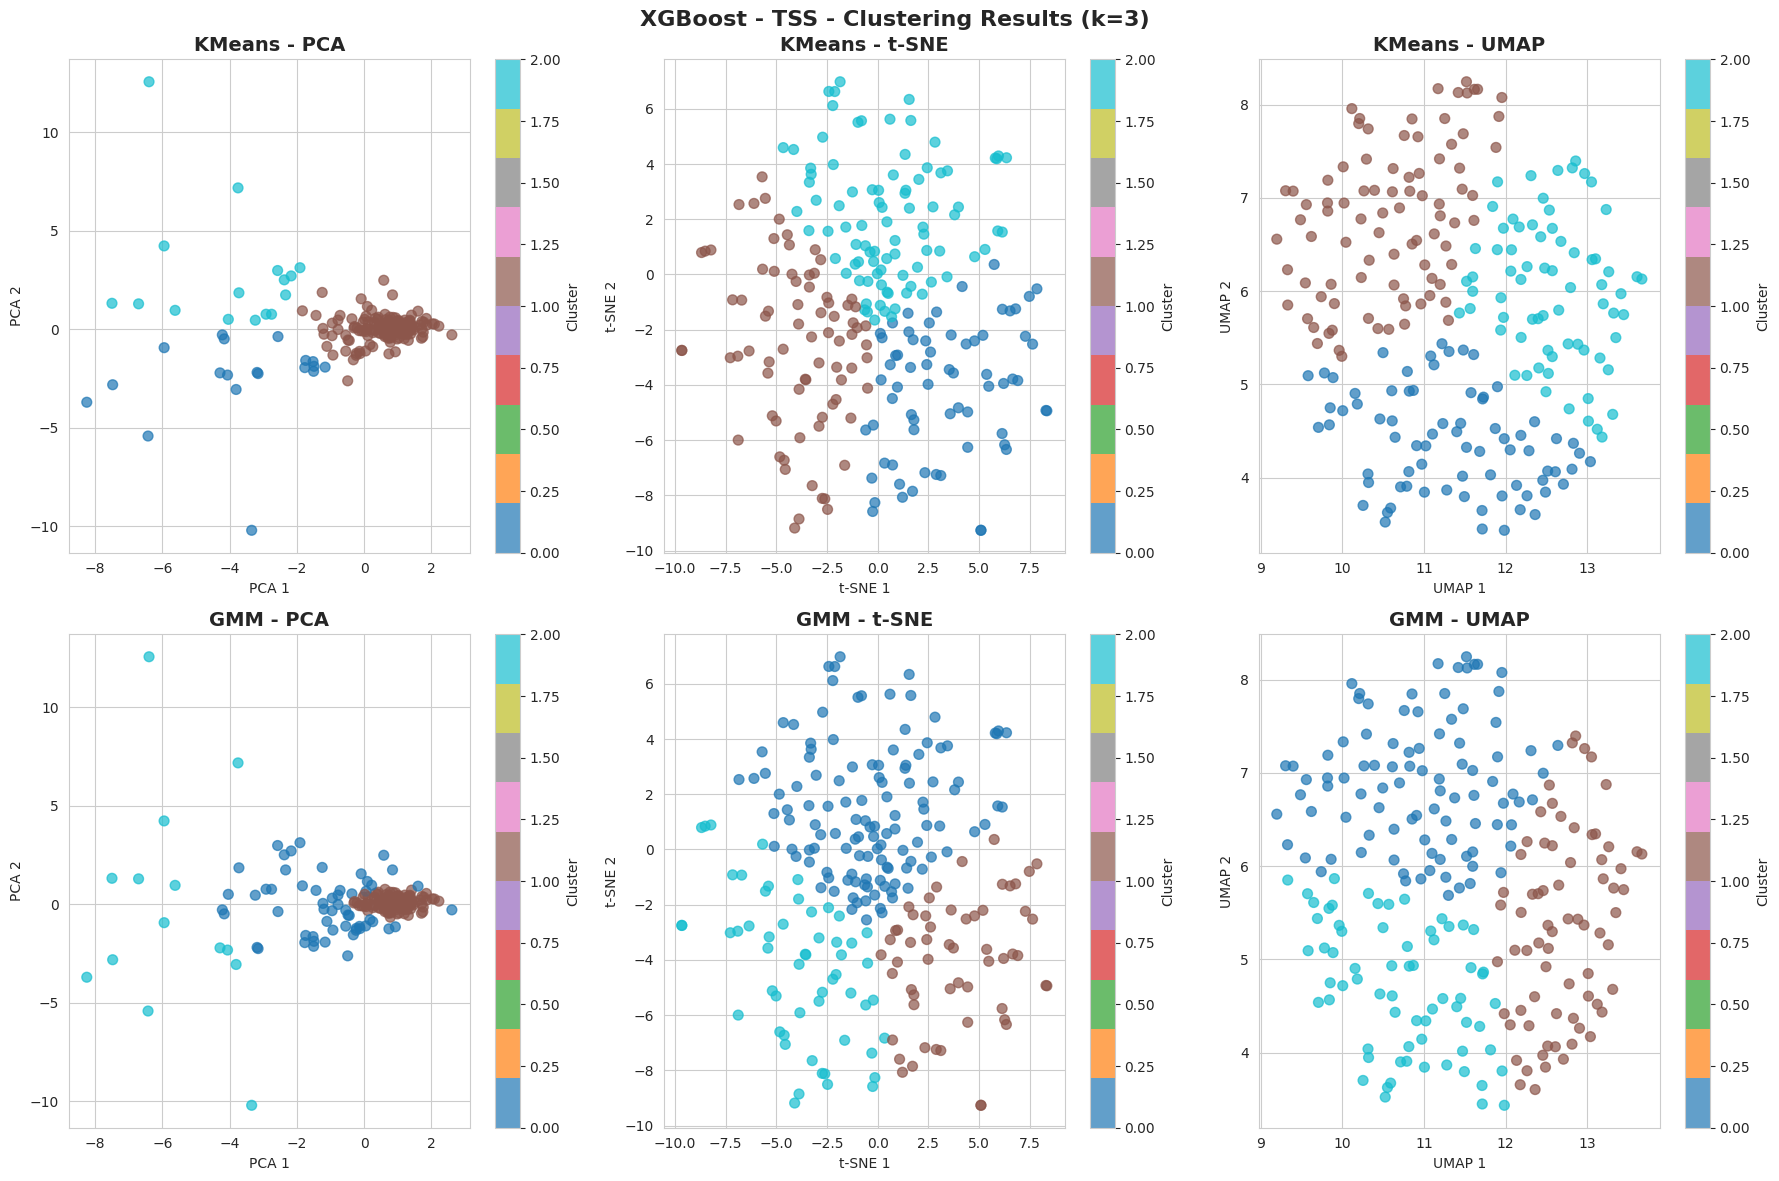

In [12]:
# Visualize TSS clustering results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

data_list = [X_tss_pca, X_tss_tsne, X_tss_umap]
kmeans_labels_list = [kmeans_labels_tss_pca, kmeans_labels_tss_tsne, kmeans_labels_tss_umap]
gmm_labels_list = [gmm_labels_tss_pca, gmm_labels_tss_tsne, gmm_labels_tss_umap]
methods = ['PCA', 't-SNE', 'UMAP']

for col, (X_reduced, kmeans_labels, gmm_labels, method) in enumerate(zip(data_list, kmeans_labels_list, gmm_labels_list, methods)):
    # KMeans clustering
    scatter = axes[0, col].scatter(X_reduced[:, 0], X_reduced[:, 1], 
                                    c=kmeans_labels, cmap='tab10', alpha=0.7, s=50)
    axes[0, col].set_title(f'KMeans - {method}', fontsize=14, fontweight='bold')
    axes[0, col].set_xlabel(f'{method} 1')
    axes[0, col].set_ylabel(f'{method} 2')
    plt.colorbar(scatter, ax=axes[0, col], label='Cluster')
    
    # GMM clustering
    scatter = axes[1, col].scatter(X_reduced[:, 0], X_reduced[:, 1], 
                                    c=gmm_labels, cmap='tab10', alpha=0.7, s=50)
    axes[1, col].set_title(f'GMM - {method}', fontsize=14, fontweight='bold')
    axes[1, col].set_xlabel(f'{method} 1')
    axes[1, col].set_ylabel(f'{method} 2')
    plt.colorbar(scatter, ax=axes[1, col], label='Cluster')

plt.suptitle(f'XGBoost - TSS - Clustering Results (k={optimal_k})', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('xgboost_tss_clustering_results_d2_k3.png', dpi=300, bbox_inches='tight')
plt.show()

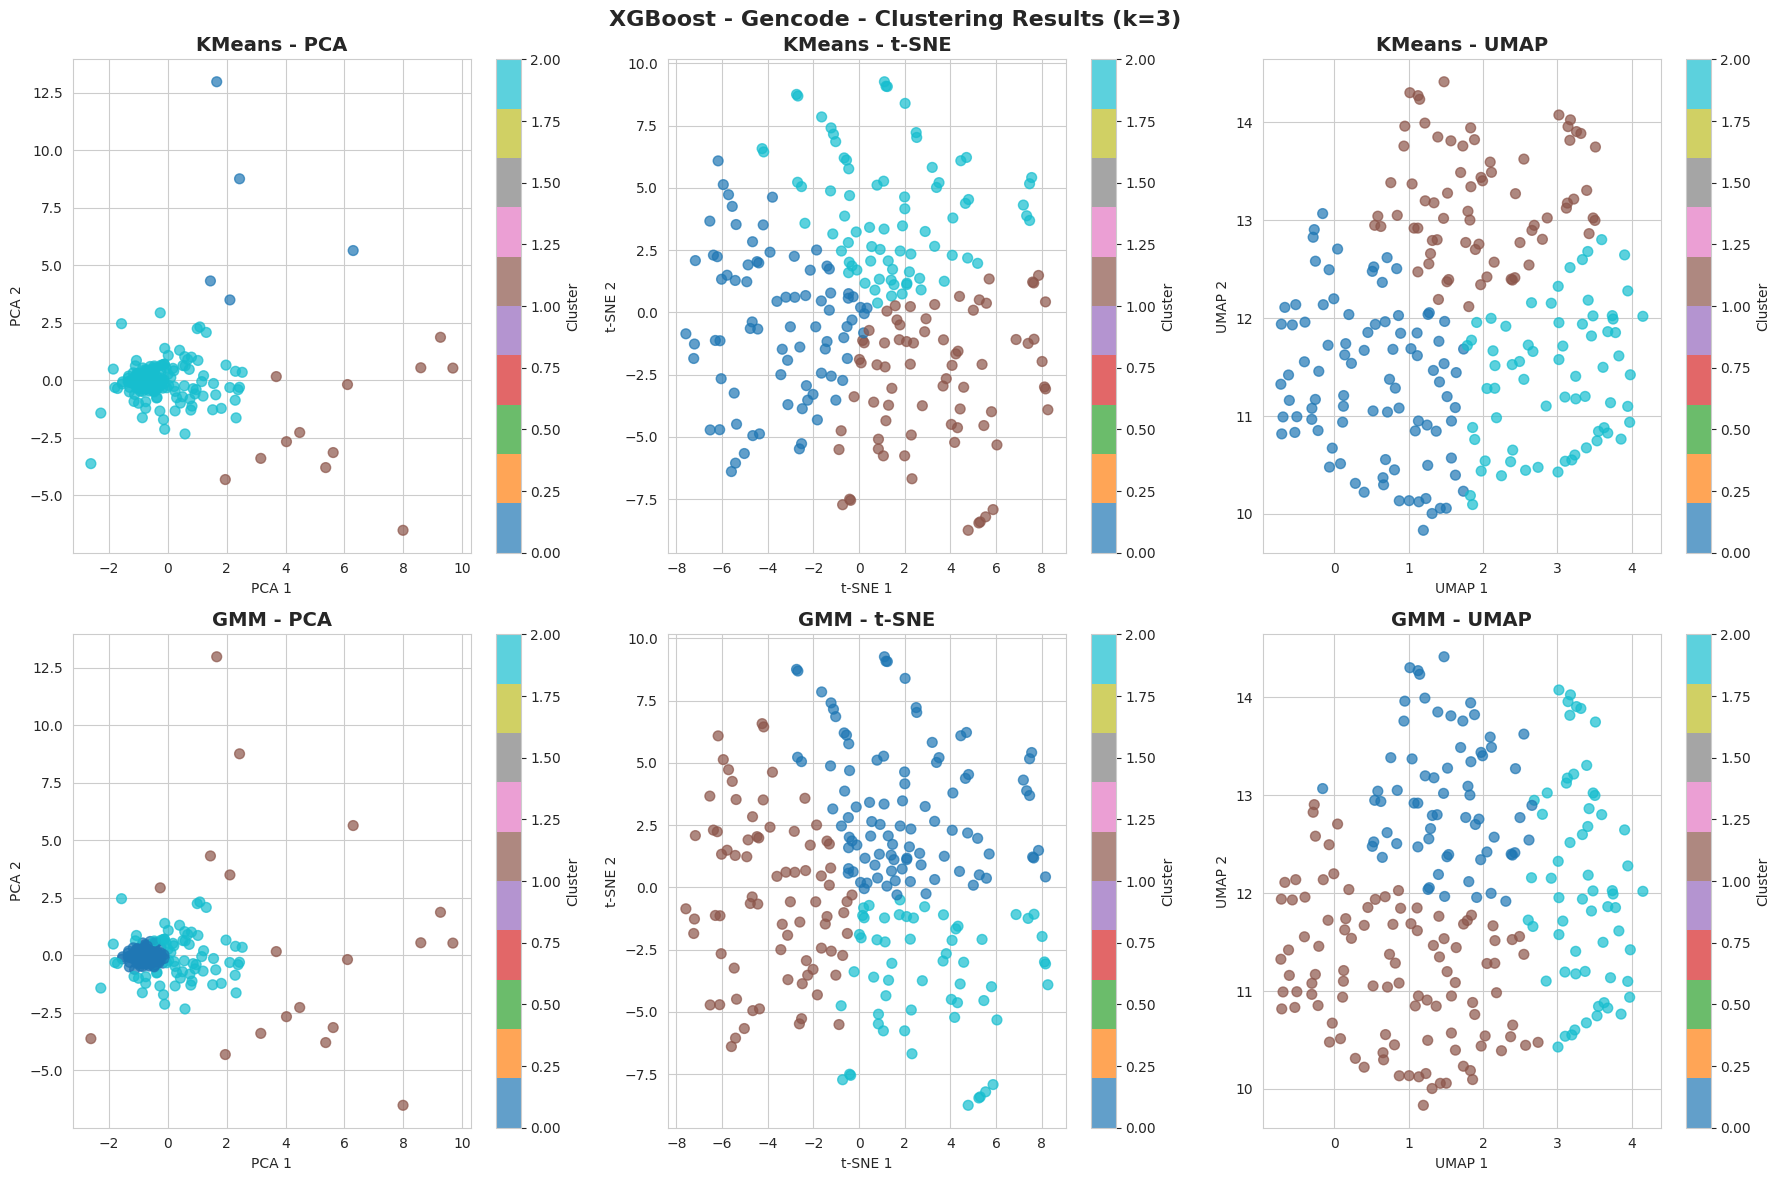

In [13]:
# Visualize Gencode clustering results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

data_list = [X_gencode_pca, X_gencode_tsne, X_gencode_umap]
kmeans_labels_list = [kmeans_labels_gencode_pca, kmeans_labels_gencode_tsne, kmeans_labels_gencode_umap]
gmm_labels_list = [gmm_labels_gencode_pca, gmm_labels_gencode_tsne, gmm_labels_gencode_umap]
methods = ['PCA', 't-SNE', 'UMAP']

for col, (X_reduced, kmeans_labels, gmm_labels, method) in enumerate(zip(data_list, kmeans_labels_list, gmm_labels_list, methods)):
    # KMeans clustering
    scatter = axes[0, col].scatter(X_reduced[:, 0], X_reduced[:, 1], 
                                    c=kmeans_labels, cmap='tab10', alpha=0.7, s=50)
    axes[0, col].set_title(f'KMeans - {method}', fontsize=14, fontweight='bold')
    axes[0, col].set_xlabel(f'{method} 1')
    axes[0, col].set_ylabel(f'{method} 2')
    plt.colorbar(scatter, ax=axes[0, col], label='Cluster')
    
    # GMM clustering
    scatter = axes[1, col].scatter(X_reduced[:, 0], X_reduced[:, 1], 
                                    c=gmm_labels, cmap='tab10', alpha=0.7, s=50)
    axes[1, col].set_title(f'GMM - {method}', fontsize=14, fontweight='bold')
    axes[1, col].set_xlabel(f'{method} 1')
    axes[1, col].set_ylabel(f'{method} 2')
    plt.colorbar(scatter, ax=axes[1, col], label='Cluster')

plt.suptitle(f'XGBoost - Gencode - Clustering Results (k={optimal_k})', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('xgboost_encode_clustering_results_d2_k3.png', dpi=300, bbox_inches='tight')
plt.show()